In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from matplotlib.gridspec import GridSpec
import pylab
import hickle as hkl
import pandas as pd

from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd


In [2]:
csv_file_path = 'cluster_summary.csv'  # Change this to your CSV file name

# Read the CSV file
df = pd.read_csv(csv_file_path)
df

,cluster_id,job_count,tech_score_center,finance_score_center,avg_annual_salary,median_annual_salary,count_annual_salary,avg_normalized_salary,median_normalized_salary,count_normalized_salary,...,normalized_std_tech_score,normalized_std_finance_score,normalized_job_value,normalized_job_value_log,normalized_efficiency,competitiveness,normalized_competitiveness,job_value_avg,tech_score_center_scaled,finance_score_center_scaled
0,0,1068,0.1,0.1,101543.303081,85000.0,1068,432365.049897,72845.00,1068,...,0.592894,0.659950,0.149739,0.230975,0.785843,0.198502,0.504526,239.426339,0.5,0.5
1,1,799,0.1,0.3,102481.031652,85000.0,799,88266.703379,75000.00,799,...,0.506611,0.000000,0.118403,0.177084,0.668877,0.245307,0.623488,186.453701,0.5,1.5
2,2,1412,0.1,0.5,106947.807805,85000.0,1412,88858.893693,75000.00,1412,...,0.657766,0.500029,0.199294,0.306725,0.703056,0.245751,0.624616,319.840594,0.5,2.5
3,3,42,0.1,0.7,107283.996905,100250.0,42,90677.187381,89954.50,42,...,0.646463,0.362854,0.006155,0.008641,0.669761,0.261905,0.665675,11.194895,0.5,3.5
4,4,821,0.1,0.9,160378.226797,150000.0,821,138389.554129,128000.00,821,...,0.714688,0.817635,0.188475,0.199535,0.687137,0.260658,0.662505,301.740435,0.5,4.5
5,5,2442,0.3,0.1,168325.246335,100000.0,2442,413067.069791,85000.00,2442,...,0.318749,0.429985,0.417444,0.557568,0.744537,0.310401,0.788937,657.728937,1.5,0.5
6,6,537,0.3,0.3,122985.672924,105000.0,537,278599.081462,90000.00,537,...,0.245993,0.193296,0.095539,0.123328,0.708497,0.271881,0.691030,151.461729,1.5,1.5
7,7,906,0.3,0.5,107056.699360,85434.0,906,91835.398687,77500.00,906,...,0.237761,0.452505,0.134708,0.199445,0.707522,0.279249,0.709759,215.915423,1.5,2.5
8,8,41,0.3,0.7,139279.682927,116516.0,41,119357.615122,103163.72,41,...,0.362609,0.454563,0.007884,0.009008,0.562972,0.268293,0.681911,13.595815,1.5,3.5
9,9,614,0.3,0.9,168017.574023,150000.0,614,139042.495049,127575.00,614,...,0.329186,0.769581,0.152144,0.153781,0.648855,0.312704,0.794788,238.656889,1.5,4.5


In [3]:
def scaling(df,colmn1,colmn2,domain_bounds=np.array([[0,5],[0,5]])):
    # Scale coordinates to match domain_bounds range [0,5] for both dimensions
    df[colmn1+'_scaled'] = df[colmn1] * (domain_bounds[0,1] - domain_bounds[0,0]) + domain_bounds[0,0]
    df[colmn2+'_scaled'] = df[colmn2]* (domain_bounds[1,1] - domain_bounds[1,0]) + domain_bounds[1,0]
    return df

In [4]:
df=scaling(df,'tech_score_center','finance_score_center')
len(df['finance_score_center'].values)

25

In [5]:
def reward_standardization(df,colmn1,colmn2,domain_bounds=np.array([[0,5],[0,5]]),metric='job_count',domain_refinement=20):
    df=scaling(df,colmn1=colmn1,colmn2=colmn2,domain_bounds=domain_bounds)
    # Create rect_positions using actual DataFrame coordinates instead of regular grid
    # This maintains the same format but uses your job market data positions

    colmn1=colmn1+'_scaled'
    colmn2=colmn2+'_scaled'
    rect_positions_x = df[colmn1].values
    rect_positions_y = df[colmn2].values
    rect_positions = np.vstack([rect_positions_x, rect_positions_y])
    rect_positions = rect_positions.transpose()
    # Create resources array directly from DataFrame values (same length as rect_positions)
    if metric in df.columns:
        resources = df['job_count'].values
    else:
        print(f'no metric {metric}')

    # Create a grid to map your DataFrame data to the mesh grid format for visualization
    # Initialize with zeros
    resources=df[metric].values
    resources_grid=np.zeros([domain_refinement,domain_refinement])
    # Map DataFrame coordinates to grid indices and fill with normalized salary values
    for idx, row in df.iterrows():
        # Convert scaled coordinates to grid indices
        idx_1 = int(np.clip(row[colmn1] / domain_bounds[0,1] * (domain_refinement-1), 0, domain_refinement-1))
        idx_2 = int(np.clip(row[colmn2] / domain_bounds[1,1] * (domain_refinement-1), 0, domain_refinement-1))
        resources_grid[idx_2, idx_1] = row[metric]
    return torch.tensor(rect_positions),resources,resources_grid




In [6]:
rect_positions,resources,_=reward_standardization(df,'tech_score_center','finance_score_center')



## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [31]:
num_agents=3
infl_configs={"infl_type":"multi_gaussian"}
domain_type='2d'
domain_bounds=np.array([[0,5],[0,5]])
domain_refinement=20
int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type="initial_symmetric_setup",domain_type=domain_type,domain_bounds=domain_bounds)
#int_agents_pos=[[7.5,7.5],[7.5,7.5],[7.5,7.5],[7.5,7.5]] 
parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=[[.5,0],[0,.5]])
#parameters=torch.tensor([[[.1,0],[0,.1]],[[.1,0],[0,.1]],[[.1,0],[0,.1]],[[.1,0],[0,.1]]])
bin_points=rect_positions
resource_distribution=resources
lr_type='cosine_annealing' #static or cosine
learning_rate=[1/10000,1/10000,250]
time_steps=1000

vis=Shell(num_agents=num_agents, agents_pos=int_agents_pos.clone(), parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points,
          infl_configs=infl_configs,learning_rate_type=lr_type,learning_rate=learning_rate,time_steps=time_steps,domain_type=domain_type,domain_bounds=domain_bounds,resource_type='custom_2d_rect',domain_refinement=domain_refinement,tolerance=.000001,ignore_zero_infl=True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix.clone()
og_grad_matrix=vis.field.grad_matrix.clone()
vis.agents_pos=int_agents_pos.clone()

In [32]:
#vis.mean_stability_birfurcation_rs(r_st=.1,r_end=.5,r_points=200,s_st=0,s_end=1,s_points=100)

#vis.first_order_bifurication_plot(vis.parameters[0],resource_distribution_type="multi_modal_gaussian_distribution_2D_square",alpha_current=current_alpha,alpha_st=0,alpha_end = 5, fixed_parameters_lst=resource_parameters_MVG)

## End State plot

Shows the players influence over the resource distribution as they move via adaptive dynamics

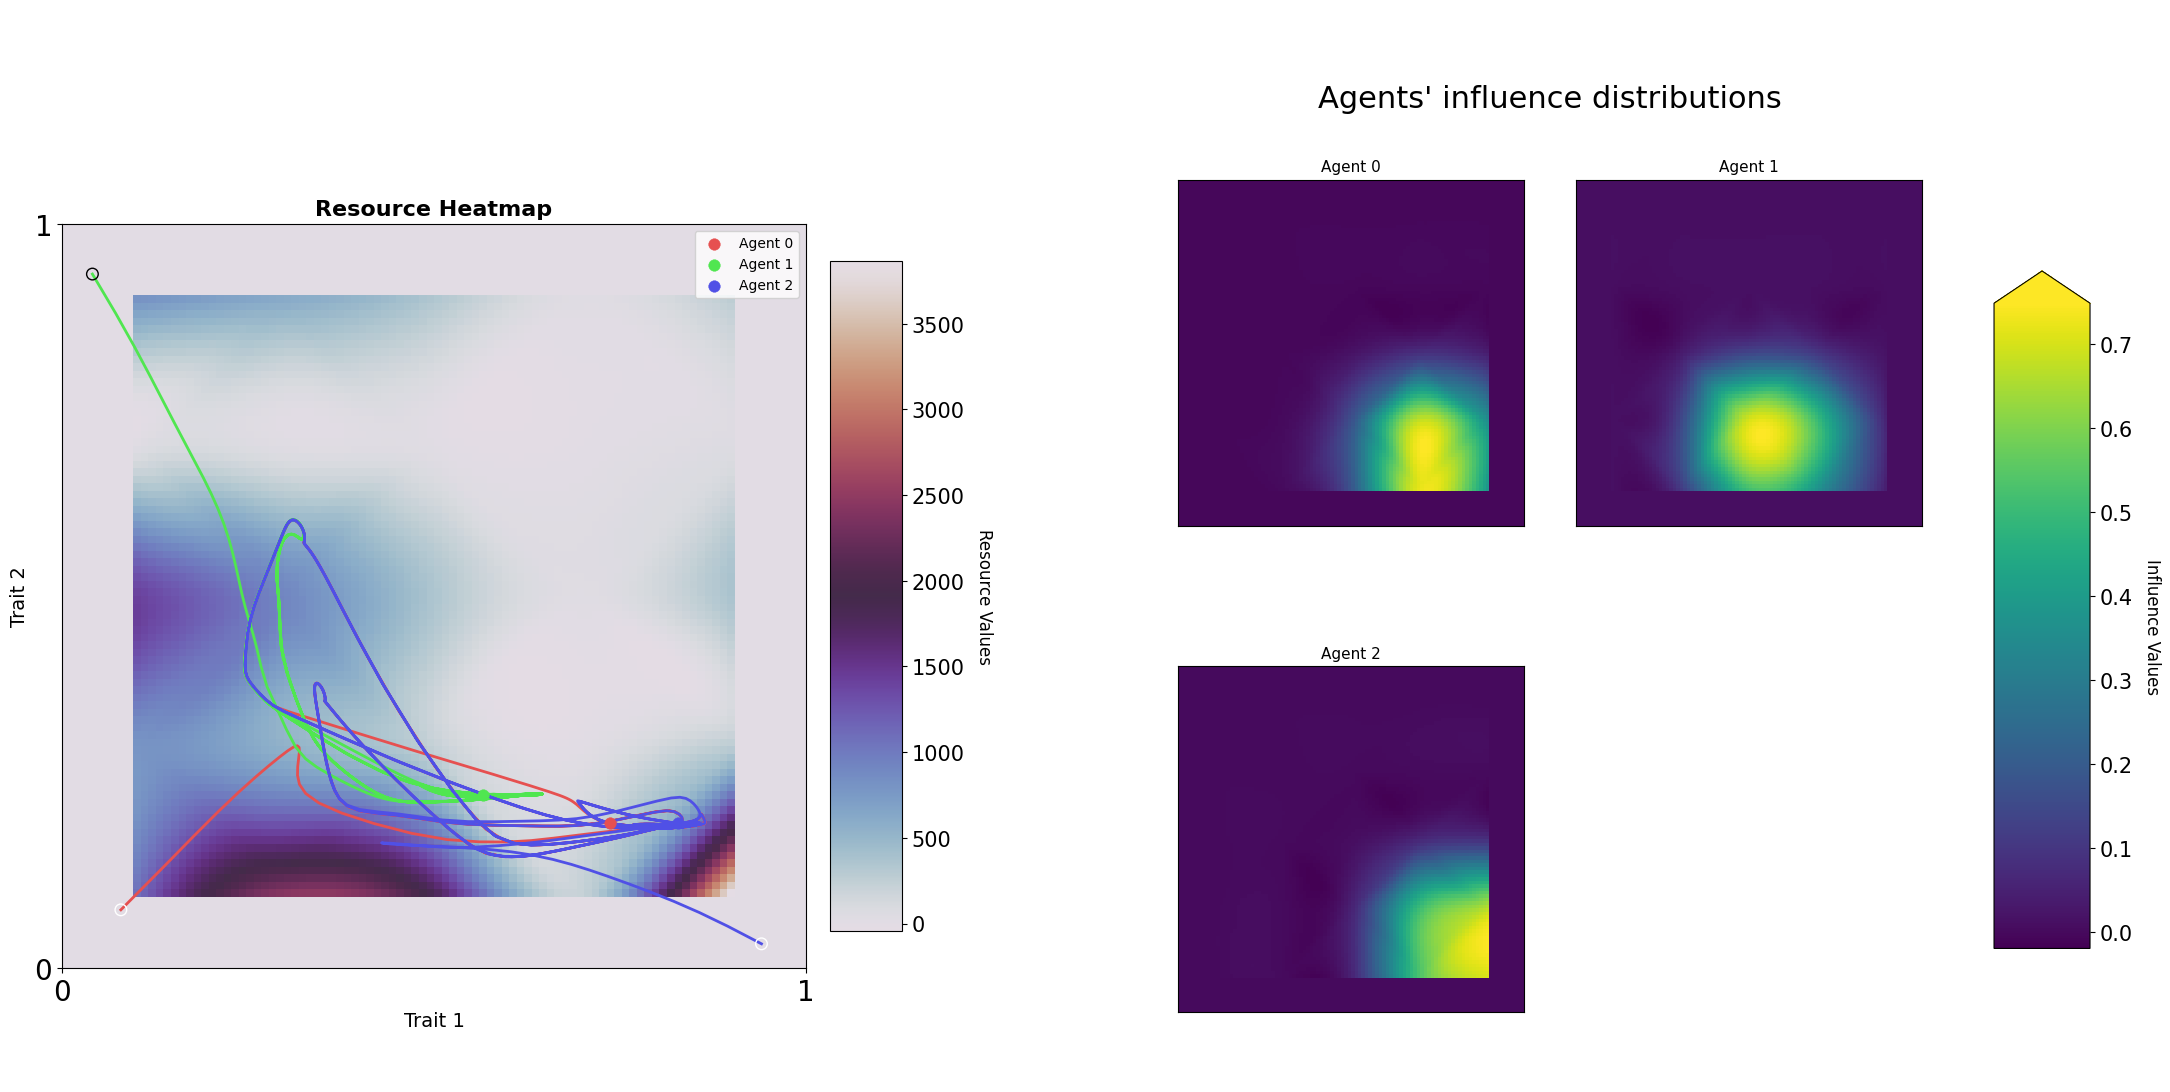

In [34]:
colmn1='tech_score_center'
colmn2='finance_score_center'
vis.dist_pos_gif(250,x_min=0,y_min=0)

## Gif State plot

gif of the above plot

In [10]:
stop

NameError: name 'stop' is not defined

In [ ]:
#vis.vect_plot(agent_id=0,parameter_instance=vis.param\eters[0],pos=vis.agents_pos)

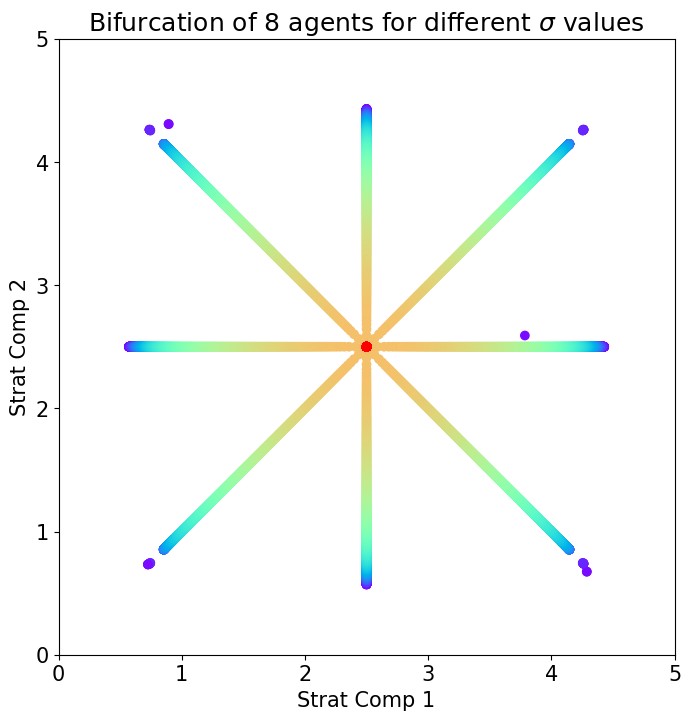

In [ ]:
test=vis.equilibrium_bifurcation_plot(reach_start=.5,
                                      reach_end=4,
                                      reach_num_points=1000,
                                      time_steps=10000,
                                      initial_pos=vis.agents_pos,
                                      name_ads=[],
                                      title_ads=[],
                                      parallel_configs={'parallel':True, 'max_workers':8, 'batch_size':4},
                                      font={'default_size': 15, 'cbar_size': 16, 'title_size': 18, 'legend_size': 12, 'font_family': 'sans-serif'},
                                      cbar_config={'center_labels': True, 'label_alignment': 'center', 'shrink': 1.0},
                                      save=True,
                                      paper_figure={'paper': True, 'section': '4_1','figure_id':'figure 7'},                                         
                                      )
vis.field.pos_matrix=og_pos_matrix.clone()
vis.field.grad_matrix=og_grad_matrix.clone()
test

In [ ]:
"""

import pylab as pl
import numpy as np

a = np.array([[.5,4]])
pl.figure(figsize=(9, .5))
img = pl.imshow(a, cmap="rainbow")
pl.gca().set_visible(False)
cax = pl.axes([0.1, 0.2, 0.8, 0.6])
pl.colorbar(orientation="horizontal", cax=cax)
plt.title(r"$\sigma$ range")
pl.savefig("2d_colorbar.svg",bbox_inches='tight')


"""


'\n\nimport pylab as pl\nimport numpy as np\n\na = np.array([[.5,4]])\npl.figure(figsize=(9, .5))\nimg = pl.imshow(a, cmap="rainbow")\npl.gca().set_visible(False)\ncax = pl.axes([0.1, 0.2, 0.8, 0.6])\npl.colorbar(orientation="horizontal", cax=cax)\nplt.title(r"$\\sigma$ range")\npl.savefig("2d_colorbar.svg",bbox_inches=\'tight\')\n\n\n'